Dataset Dimensions: 95662 rows, 16 columns

--- Data Information Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object

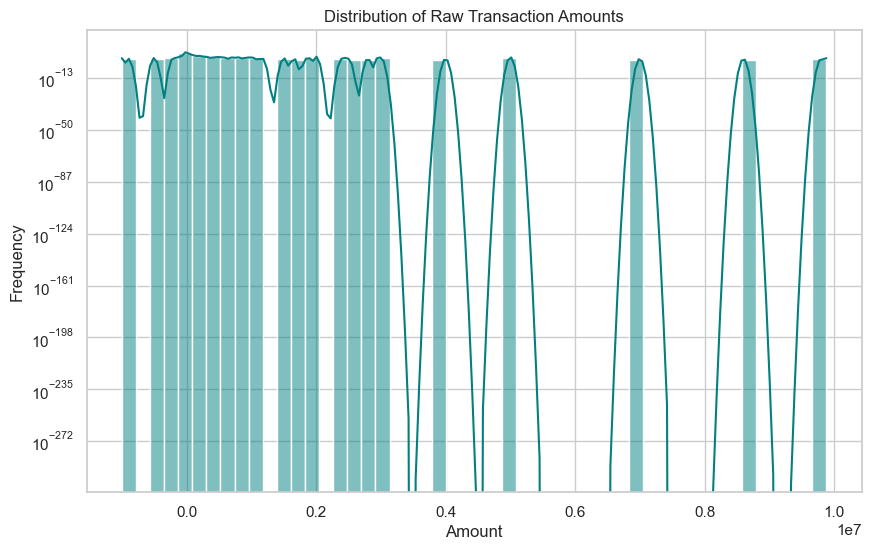

C:\Users\coop\AppData\Local\Temp\ipykernel_26384\1372341216.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FraudResult', palette='Set2')


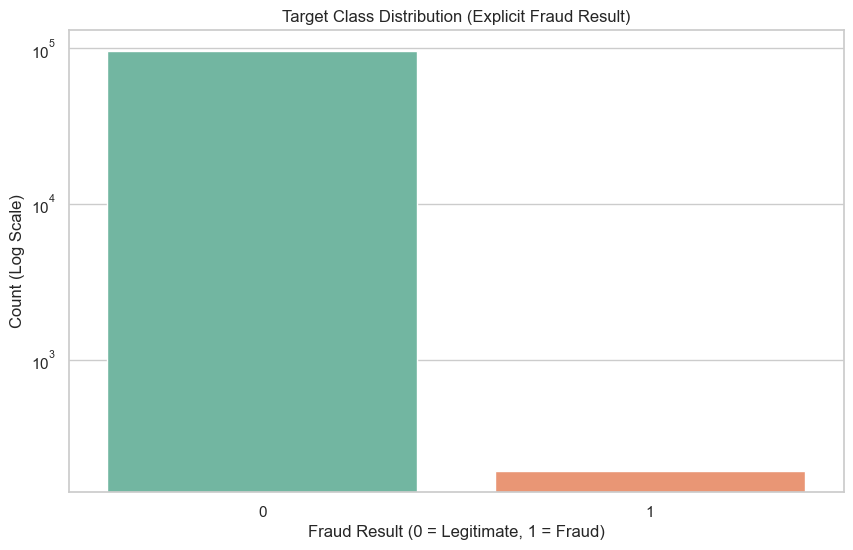

C:\Users\coop\AppData\Local\Temp\ipykernel_26384\1372341216.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ProductCategory', y='Value', palette='Set3')


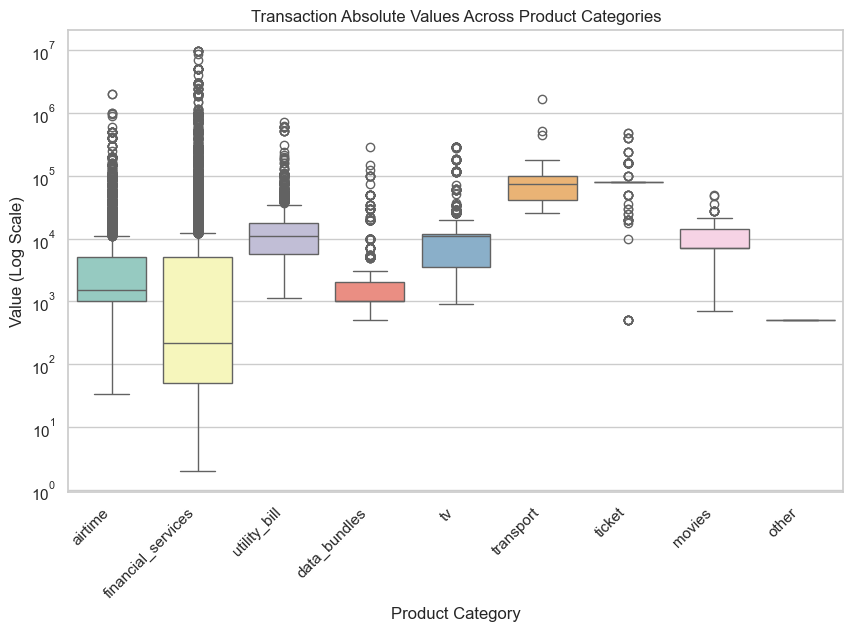

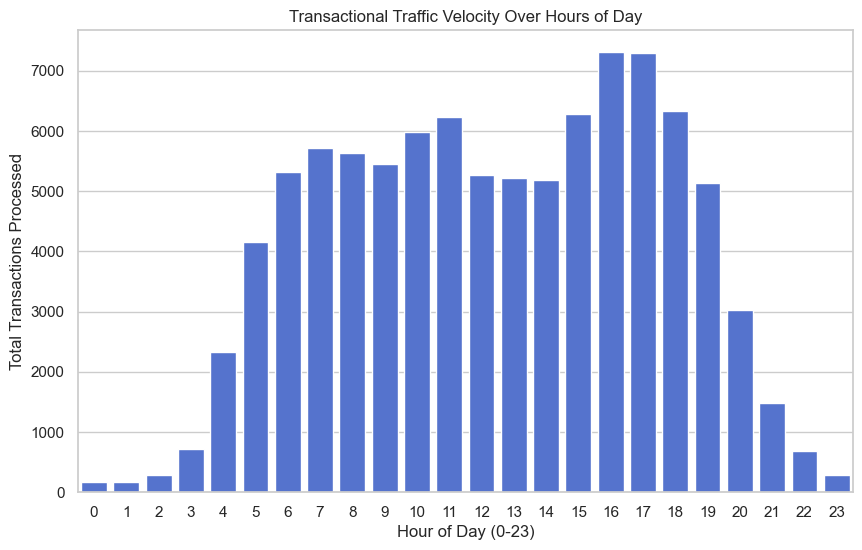

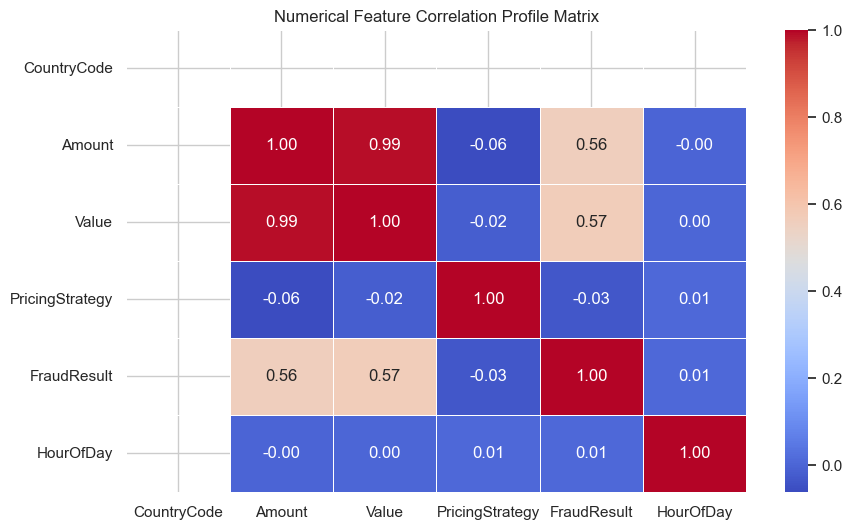

In [1]:
# %% [markdown]
# # Task 2: Exploratory Data Analysis (EDA)
# **Project:** Bati Bank Alternative Credit Risk Model  
# **Objective:** Characterize data anomalies, distributions, missingness, and structural feature relationships.

# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual preferences
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Define data paths
RAW_DATA_PATH = "../data/raw/data.csv"
OUTPUT_IMG_DIR = "../notebooks/plots/"
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)

# Load data
df = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

# %% [markdown]
# ### 1. Schema, Information, and Missing Values Analysis

# %%
print("--- Data Information Summary ---")
print(df.info())

print("\n--- Missing Value Counts ---")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "Zero missing values detected across all columns.")

# %% [markdown]
# ### 2. Cardinality Analysis of Categorical & ID Features

# %%
print("--- Cardinality (Unique Values) Per Column ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# %% [markdown]
# ### 3. Descriptive Statistical Summary for Numerical Features

# %%
print("\n--- Descriptive Statistics ---")
df[['Amount', 'Value', 'PricingStrategy']].describe().T

# %% [markdown]
# ### 4. Distribution Analysis: Visualizing Key Metrics
# Let's inspect `Amount` and the `FraudResult` distribution to observe the skewness.

# %%
# Transaction Amount Distribution Plot
plt.figure()
sns.histplot(df['Amount'], bins=50, kde=True, color='teal')
plt.title('Distribution of Raw Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.yscale('log') # Log scale to view extreme distributions safely
plt.savefig(os.path.join(OUTPUT_IMG_DIR, 'amount_distribution.png'), bbox_inches='tight')
plt.show()

# Fraud Result Class Imbalance
plt.figure()
sns.countplot(data=df, x='FraudResult', palette='Set2')
plt.title('Target Class Distribution (Explicit Fraud Result)')
plt.xlabel('Fraud Result (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count (Log Scale)')
plt.yscale('log')
plt.savefig(os.path.join(OUTPUT_IMG_DIR, 'fraud_distribution.png'), bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 5. Outlier Profiling via Boxplots

# %%
plt.figure()
sns.boxplot(data=df, x='ProductCategory', y='Value', palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Transaction Absolute Values Across Product Categories')
plt.yscale('log')
plt.xlabel('Product Category')
plt.ylabel('Value (Log Scale)')
plt.savefig(os.path.join(OUTPUT_IMG_DIR, 'value_outliers_by_category.png'), bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6. Temporal and Correlation Analysis

# %%
# Convert transaction timestamps
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['HourOfDay'] = df['TransactionStartTime'].dt.hour

# Visualize intraday velocity patterns
plt.figure()
sns.countplot(data=df, x='HourOfDay', color='royalblue')
plt.title('Transactional Traffic Velocity Over Hours of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Total Transactions Processed')
plt.savefig(os.path.join(OUTPUT_IMG_DIR, 'hourly_traffic.png'), bbox_inches='tight')
plt.show()

# Numerical Feature Matrix Correlation Heatmap
plt.figure()
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Profile Matrix')
plt.savefig(os.path.join(OUTPUT_IMG_DIR, 'correlation_matrix.png'), bbox_inches='tight')
plt.show()